In [1]:
import numpy as np
import pandas as pd
import os.path as op
import os
import pingouin
import matplotlib.pyplot as plt
import seaborn as sns

# in utils get_stress_level(): AUC per subject from ('/Users/mrenke/Desktop/StressRisk/2022-StressRisk/Data-Final/auc_cortisol.xlsx')


In [2]:
# prepare column names (stress measure from 8 different time points)
col_ofin_name = 'q_stress'
cols_ofin = [] # {}
for n in range(1,8):
    cols_ofin.append(col_ofin_name  + f'_{n}')

/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package outdated is out of date. Your version is 0.2.1, the latest is 0.2.2.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(
/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.2, the latest is 0.5.3.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [3]:
df_comb = pd.read_excel('/Users/mrenke/Desktop/StressRisk/gokis_code/data_combined.xlsx')
df_comb = df_comb.rename(columns={'SUBID':'subject', 'condition':'group'}).set_index(['subject', 'group'])
df = df_comb[cols_ofin]
df.head()

,,q_stress_1,q_stress_2,q_stress_3,q_stress_4,q_stress_5,q_stress_6,q_stress_7
subject,group,,,,,,,
1,0,5,5,4,5,5,5,4
2,0,2,2,2,2,2,2,1
3,1,5,6,5,5,6,2,3
4,1,4,5,6,5,5,4,3
5,0,1,2,2,1,3,1,1


In [15]:
def auc(x,y):
    total_area = np.trapz(y, x)

    # Calculate the area of the trapezoid
    baseline_area = (x[-1] - x[0]) * (y[0] + y[-1]) / 2

    # Subtract to get the area between the curve and the baseline
    area_between = total_area - baseline_area
    return area_between


In [81]:
x=range(1,4)
y=[1,2,0]

print(np.trapz(y, x))
baseline_area = (x[-1] - x[0]) * (y[0] + y[-1]) / 2
print(baseline_area)
auc(x,y)

2.5
1.0


1.5

In [16]:
from sklearn import metrics

df = df.copy() # gave me a weird warning before

df['mean_stress'] = df.mean(axis=1)
df['min-max_diff'] = df.apply(lambda row: row[cols_ofin].max() - row[cols_ofin].min(), axis=1)
df['sd_stress'] = df.std(axis=1)
df['auc_stress_old'] = df.apply(lambda row: metrics.auc(range(1,8),row[cols_ofin]), axis=1) # not sure if this is doing it the way I want: metrics.auc(range(1,7), [10, 10, 10, 10, 10, 10])
df['auc_stress'] = df.apply(lambda row: auc(range(1,8),row[cols_ofin]), axis=1) # not sure if this is doing it the way I want: metrics.auc(range(1,7), [10, 10, 10, 10, 10, 10])

df['group'] = np.where(df.reset_index()['group'] == 0, 'control', 'stress') 


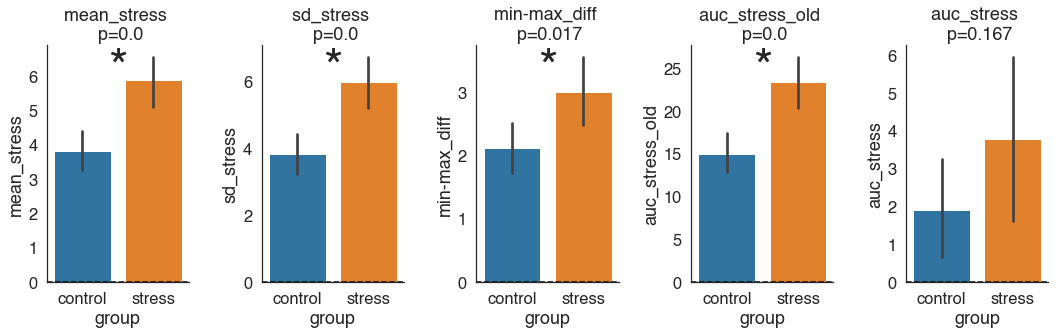

In [75]:
from scipy.stats import ttest_ind

#sns.set_theme('paper', 'white', font='helvetica', font_scale=2, palette='tab10')
sns.set_context('notebook', font_scale=1.5)
col_names = ['mean_stress', 'sd_stress', 'min-max_diff', 'auc_stress_old','auc_stress']
fig, axs = plt.subplots(1, len(col_names), figsize=(15, 5))

for ax, column in zip(axs, col_names):
    sns.barplot(data=df, y=column, x='group', ax=ax)
    ax.axhline(0, color='black', linestyle='--')
    t_stat, p_val = ttest_ind(df.xs(0,0,'group')[column], df.xs(1,0,'group')[column])
    ax.set_title(f'{column} \n p={np.round(p_val,3)}')
    if p_val < 0.05:
        ax.text(0.5, 0.8, '*', transform=ax.transAxes, ha='center', va='bottom',fontsize=50) 

plt.tight_layout()
sns.despine()
plt.show()

In [76]:
df['mean_stress'].to_csv('/Users/mrenke/data/ds-stressrisk/addMeasures/selfRated_Stress.csv')
df.to_csv('/Users/mrenke/data/ds-stressrisk/addMeasures/selfRated_Stress_allMeasures.csv')

In [74]:
len(df.index.unique(level='subject'))

50

In [37]:
# copied from analyse_results/utils.get_stress_level()

df_auc = pd.read_excel('/Users/mrenke/Desktop/StressRisk/2022-StressRisk/Data-Final/auc_cortisol.xlsx')
df_auc = df_auc.rename(columns={'SubjectID':'subject'}).set_index('subject')[['AUC']] # double brackets --> dataframe
df_auc = df_auc[['AUC']].groupby('subject').mean()
df = df.join(df_auc)

Text(0.5, 1.0, 'group all \n r=0.28, p= 0.05377')

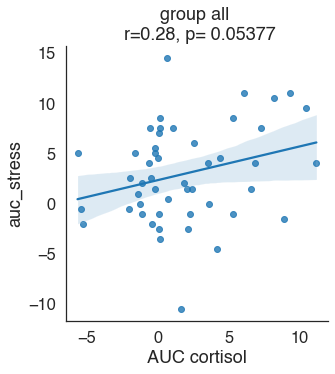

In [39]:
# testing which metric on self-rated-stress-level correlates best with AUC-cortisol

gr = 'all'
t = df#.xs(gr,0,'group')
var2 = 'auc_stress' #'min-max_diff'#'sd_stress'# 'auc_stress'#'mean_stress'
sns.lmplot(data=df.reset_index() , x='AUC', y = var2) #, hue='group')
cor = pingouin.corr(t['AUC'], t[var2])
r_ = np.round(cor['r'][0], 2)
p = np.round(cor['p-val'][0], 5)
plt.xlabel('AUC cortisol')
plt.title(f'group {gr} \n r={r_}, p= {p}')